# Vortex cluster data generation
This notebook generates the synthetic data used to train and evaluate the vortex-classification and inverse models. Initial vorticity fields are constructed from small clusters of smooth vortices on a periodic two-dimensional domain and then evolved forward in time with a Fourier Navier-Stokes solver.

The primary datasets consist of four vortex families: same sign pairs, opposite sign pairs, same sign triples, and mixed sign triples. For each sample, both the initial and evolved vorticity fields are retained together with the parameters describing the initial vortices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from pathlib import Path
from tqdm.auto import tqdm

# Global settings
Here we set the most important parameters for the problem, like the size of the domain (the torus), the closeness of vortices in clusters, and the ranges of parameters we vary in the vortices generated. By choosing a periodic domain like the torus, we simplify boundary conditions and effects for the Navier-Stokes evolution.

In [2]:
L = np.pi # We choose a torus of length pi and width pi.
N = 128   # This determines the grid resolution.
K_max = 3 # This is the max number of vortices we want to generate in our samples.

# Cluster distance range. This is chosen so that the vortices are initially close enough for us to observe interactions over our time window.
cluster_distance_min = 0.3
cluster_distance_max = 0.4

# Stronger amplitudes make cluster structure more visible and encourage interactions for us to observe.
amp_min = 10.0
amp_max = 15.0

# Approximate Gaussian widths/standard deviations for individual vortices
sigma_min = 0.10
sigma_max = 0.16

# Reproducible random generator
rng = np.random.default_rng(1234)

# Periodic grid
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# Periodic vortex constructor
Each individual vortex is represented by a smooth periodic Gaussian-like profile parameterized by its center $(x_0,y_0)$, amplitude, and width $\sigma$. The periodic form avoids introducing a discontinuity across the edge of our torus (a periodic domain).

A complete initial vorticity field is obtained by summing the profiles of all active vortices in the sample.

In [3]:
def periodic_gaussian_vortex(X, Y, x0, y0, amp, sigma):
    """
    Creates a smooth periodic Gaussian-like vortex on the torus.

    sigma is approximately the standard deviation (the "width") of the periodic Gaussian produced.
    """
    theta_x = 2*np.pi*(X - x0)/L
    theta_y = 2*np.pi*(Y - y0)/L
    sigma_theta = (2*np.pi/L) * sigma

    exponent = (-2.0 + np.cos(theta_x) + np.cos(theta_y)) / (sigma_theta**2)
    return amp * np.exp(exponent)

def make_vorticity_field(params, mask):
    """
    Renders a vorticity field from an array of parameters for building one.

    params has shape (K_max, 4), with columns [x0, y0, amp, sigma].
    mask has shape (K_max,), and tells us which rows correspond to vortices to be generated in the field.
    """
    omega = np.zeros_like(X, dtype=np.float32)
    for row, active in zip(params, mask):
        if active:
            x0, y0, amp, sigma = row
            omega += periodic_gaussian_vortex(X, Y, x0, y0, amp, sigma)
    return omega

# Pattern constructors
The functions below generate the starting vortex configurations used throughout the project. Pair samples consist of two vortices separated by a randomly chosen distance and orientation. Triple samples are initialized at the vertices of an equilateral triangle with random orientation.

Among these geometric configurations, the vortex signs then determine four main families: same sign pairs ((+,+) or (-,-)), opposite sign pairs (+,-), same sign triples ((+,+,+) or (-,-,-)), and mixed sign triples ((+,+,-) or (-,-,+)). Vortex amplitudes and widths are sampled independently from the ranges specified above, and the completed parameter arrays are randomly shuffled so that the ordering of vortices carries no information.

In [4]:
def sample_center():
    return rng.uniform(-L/2, L/2, size=2)

def sample_sigma():
    return rng.uniform(sigma_min, sigma_max)

def sample_abs_amp():
    return rng.uniform(amp_min, amp_max)

def pair_offsets(distance, theta):
    unit = np.array([np.cos(theta), np.sin(theta)])
    return np.array([-0.5*distance*unit, 0.5*distance*unit])

def triple_offsets(pair_separation, theta):
    """Equilateral triangle with side length pair_separation."""
    r = pair_separation / np.sqrt(3.0) # Circumscribing radius for triangle
    angles = theta + np.array([0, 2*np.pi/3, 4*np.pi/3])
    return np.stack([r*np.cos(angles), r*np.sin(angles)], axis=1)

def wrap_to_domain(z):
    """Wrap coordinate/s to the periodic interval of length L, [-L/2, L/2)."""
    return ((z + L/2) % L) - L/2

def add_vortex(params_list, x0, y0, sign):
    amp = sign * sample_abs_amp()
    sigma = sample_sigma()
    params_list.append([wrap_to_domain(x0), wrap_to_domain(y0), amp, sigma])

def make_pattern_sample(pattern):
    """
    Make one padded vortex parameter sample with a prescribed cluster pattern.

    Returns:
        params: shape (K_max, 4)
        mask: shape (K_max,)
        n: number of active vortices
    """

    params_list = []

    if pattern in ["same_sign_pair", "opposite_sign_pair"]:
        d = rng.uniform(cluster_distance_min, cluster_distance_max)
        theta = rng.uniform(0, 2*np.pi)
        offsets = pair_offsets(d, theta)
        cx, cy = sample_center()

        base_sign = rng.choice([-1, 1])
        if pattern == "same_sign_pair":
            signs = [base_sign, base_sign]
        else:
            signs = [base_sign, -base_sign]

        for offset, sign in zip(offsets, signs):
            add_vortex(params_list, cx + offset[0], cy + offset[1], sign)

    elif pattern in ["same_sign_triple", "mixed_sign_triple"]:
        d = rng.uniform(cluster_distance_min, cluster_distance_max)
        theta = rng.uniform(0, 2*np.pi)
        offsets = triple_offsets(d, theta)
        cx, cy = sample_center()

        base_sign = rng.choice([-1, 1])
        if pattern == "same_sign_triple":
            signs = [base_sign, base_sign, base_sign]
        else:
            # Two of one sign, one of the other.
            signs = [base_sign, base_sign, -base_sign]
            rng.shuffle(signs)

        for offset, sign in zip(offsets, signs):
            add_vortex(params_list, cx + offset[0], cy + offset[1], sign)

    else:
        raise ValueError(f"Unknown pattern: {pattern}")

    n = len(params_list)
    params = np.zeros((K_max, 4), dtype=np.float32)
    mask = np.zeros(K_max, dtype=bool)

    params[:n] = params_list
    mask[:n] = True
    
    return params, mask, n

# Dataset generator

In [5]:
def generate_dataset(num_samples, pattern):
    """
    Generate num_samples examples of a specified cluster pattern.

    Returns a dictionary containing omega0, parameters, active_vortex_mask, vortex_count, pattern_name
    """

    omega0 = np.zeros((num_samples, N, N), dtype=np.float32)
    parameters = np.zeros((num_samples, K_max, 4), dtype=np.float32)
    active_vortex_mask = np.zeros((num_samples, K_max), dtype=bool)
    vortex_count = np.zeros(num_samples, dtype=int)

    for s in tqdm(range(num_samples), desc=f"generating {pattern} samples"):

        params, mask, n = make_pattern_sample(pattern)

        parameters[s] = params
        active_vortex_mask[s] = mask
        vortex_count[s] = n
        omega0[s] = make_vorticity_field(params, mask)

    data = {
        "omega0": omega0,
        "parameters": parameters,
        "active_vortex_mask": active_vortex_mask,
        "vortex_count": vortex_count,
        "pattern_name": pattern
    }

    return data

# Navier-Stokes solver
The generated initial vorticity fields are evolved according to the two-dimensional incompressible Navier-Stokes equations in vorticity form,

$\omega_t + u\cdot\nabla\omega = \nu\Delta\omega,$

with the velocity recovered from the stream function through

$u=\nabla^\perp\psi, \qquad \Delta\psi=-\omega$.

Because the computational domain is periodic, spatial derivatives and the Poisson equation for the stream function are evaluated using Fourier transforms. The nonlinear transport term is then formed in physical space, and time evolution is performed with fourth-order Runge-Kutta time stepping.

The solver is implemented in PyTorch so that batches of vorticity fields can be evolved on the GPU when available.

In [6]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fourier wave numbers for the L x L torus
kx_np = 2*np.pi*np.fft.fftfreq(N, d=L/N)
ky_np = 2*np.pi*np.fft.fftfreq(N, d=L/N)
KX_np, KY_np = np.meshgrid(kx_np, ky_np)
K2_np = KX_np**2 + KY_np**2
K2_safe_np = K2_np.copy()
K2_safe_np[0, 0] = 1.0

# Moves wave number arrays to the selected device
KX_t = torch.as_tensor(KX_np, dtype=torch.float32, device=gpu_device)
KY_t = torch.as_tensor(KY_np, dtype=torch.float32, device=gpu_device)
K2_t = torch.as_tensor(K2_np, dtype=torch.float32, device=gpu_device)
K2_safe_t = torch.as_tensor(K2_safe_np, dtype=torch.float32, device=gpu_device)


@torch.no_grad()
def velocity_from_vorticity(omega):
    """
    omega has shape (B, N, N) on the device.
    Returns u, v, each shape (B, N, N).
    """
    omega_hat = torch.fft.fft2(omega)

    # Delta psi = -omega, so psi_hat = omega_hat / |k|^2 for nonzero k.
    psi_hat = omega_hat / K2_safe_t
    psi_hat[:, 0, 0] = 0.0

    u_hat = 1j * KY_t * psi_hat
    v_hat = -1j * KX_t * psi_hat

    u = torch.fft.ifft2(u_hat).real
    v = torch.fft.ifft2(v_hat).real
    return u, v


@torch.no_grad()
def rhs_vorticity(omega, nu):
    """Right-hand side of omega_t + u dot grad omega = nu Delta omega."""
    omega_hat = torch.fft.fft2(omega)

    omega_x = torch.fft.ifft2(1j * KX_t * omega_hat).real
    omega_y = torch.fft.ifft2(1j * KY_t * omega_hat).real
    lap_omega = torch.fft.ifft2(-K2_t * omega_hat).real

    u, v = velocity_from_vorticity(omega)
    transport = -(u * omega_x + v * omega_y)
    diffusion = nu * lap_omega
    return transport + diffusion


@torch.no_grad()
def rk4_step(omega, dt, nu):
    k1 = rhs_vorticity(omega, nu)
    k2 = rhs_vorticity(omega + 0.5 * dt * k1, nu)
    k3 = rhs_vorticity(omega + 0.5 * dt * k2, nu)
    k4 = rhs_vorticity(omega + dt * k3, nu)
    return omega + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


@torch.no_grad()
def evolve_vorticity_batch(omega0_batch, nu=0.001, dt=0.005, num_steps=1000):
    """
    Evolve a batch of samples on the device.

    Input:
        omega0_batch: NumPy array or torch Tensor, shape (B, N, N) or (N, N)

    Output:
        torch Tensor on the device, shape (B, N, N)
    """
    omega = torch.as_tensor(omega0_batch, dtype=torch.float32, device=gpu_device)

    for _ in range(num_steps):
        omega = rk4_step(omega, dt, nu)

    return omega


@torch.no_grad()
def evolve_dataset(omega0, nu=0.001, dt=0.005, num_steps=1000, batch_size=64):
    """Evolve a whole dataset in batches on the device and return a NumPy array on CPU."""
    omegaT = np.zeros_like(omega0)
    num_samples = omega0.shape[0]

    for start in tqdm(range(0, num_samples, batch_size), desc="evolving samples"):
        stop = min(start + batch_size, num_samples)
        omega_batch_gpu = evolve_vorticity_batch(omega0[start:stop], nu, dt, num_steps)
        omegaT[start:stop] = omega_batch_gpu.detach().cpu().numpy()

    return omegaT

# Sample plotter

In [7]:
def plot_sample(data, idx):
    """
    Plots omega0 and omegaT for one generated sample.
    """

    omega0 = data["omega0"][idx]
    omegaT = data["omegaT"][idx]

    params = data["parameters"][idx]

    pattern = data.get("pattern_name")


    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    T_label = f"T={T_final:g}"

    fields = [omega0, omegaT]
    titles = [f"omega0, sample {idx}: {pattern}", f"omegaT, {T_label}"]

    max_abs = max(float(np.max(np.abs(field))) for field in fields)
    vmin, vmax = -max_abs, max_abs

    for ax, field, title in zip(axes, fields, titles):
        im = ax.imshow(
            field,
            origin="lower",
            extent=[-L/2, L/2, -L/2, L/2],
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.colorbar(im, ax=axes, shrink=0.85, label="omega")
    plt.show()

# Generate and evolve datasets
For each vortex family, the desired number of initial samples is first generated and then evolved forward using the solver above. The evolution parameters used for the datasets in this project are viscosity $\nu=0.001$, time step $\Delta t=0.005$, and 350 time steps, giving a final observation time of $T=1.75$.

The resulting dataset retains the initial field $\omega(0)$, the evolved field $\omega(T)$, and the parameters describing each initial vortex configuration.

In [8]:
NUM_SAMPLES = 1000
PATTERN = "mixed_sign_triple" # Choose one of same_sign_pair, opposite_sign_pair, same_sign_triple, mixed_sign_triple

nu = 0.001
dt = 0.005
num_steps = 350
T_final = dt * num_steps

full_data = generate_dataset(NUM_SAMPLES, PATTERN)

full_data["omegaT"] = evolve_dataset(full_data["omega0"], nu, dt, num_steps)

print("pattern:", full_data["pattern_name"])
print("omega0:", full_data["omega0"].shape)
print("parameters:", full_data["parameters"].shape)
print("active_vortex_mask:", full_data["active_vortex_mask"].shape)
print("vortex_count:", full_data["vortex_count"].shape)
print("omegaT:", full_data["omegaT"].shape)

generating mixed_sign_triple samples:   0%|          | 0/1000 [00:00<?, ?it/s]

evolving samples:   0%|          | 0/16 [00:00<?, ?it/s]

pattern: mixed_sign_triple
omega0: (1000, 128, 128)
parameters: (1000, 3, 4)
active_vortex_mask: (1000, 3)
vortex_count: (1000,)
omegaT: (1000, 128, 128)


# Inspect generated examples

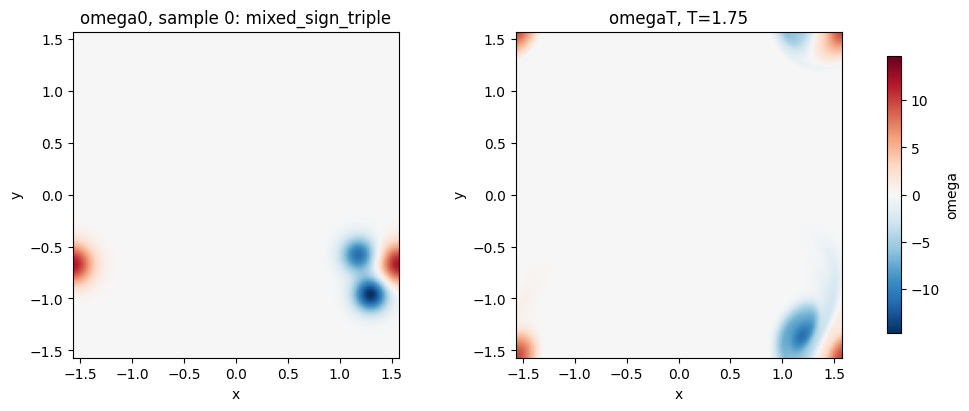

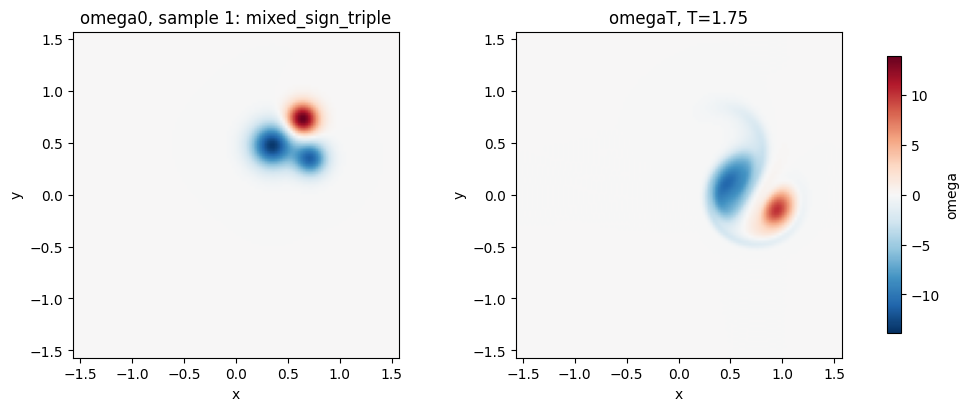

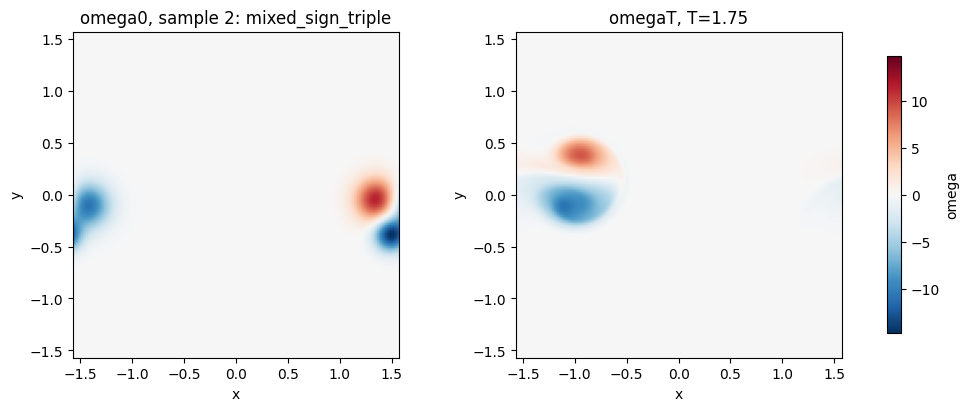

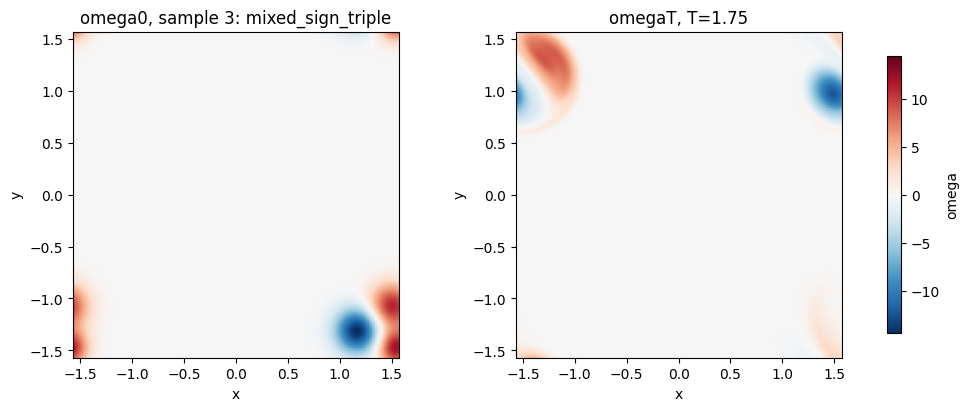

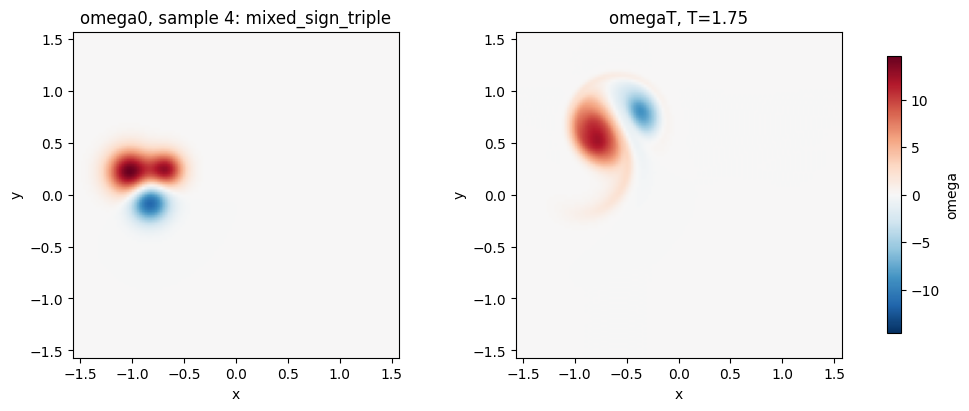

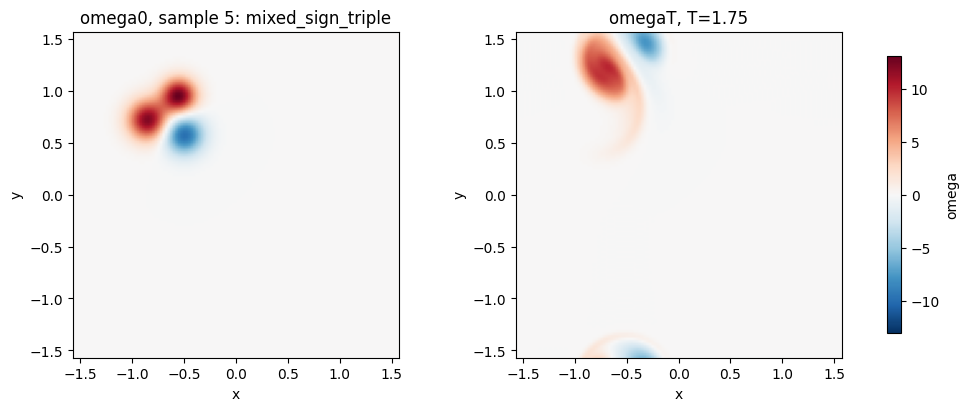

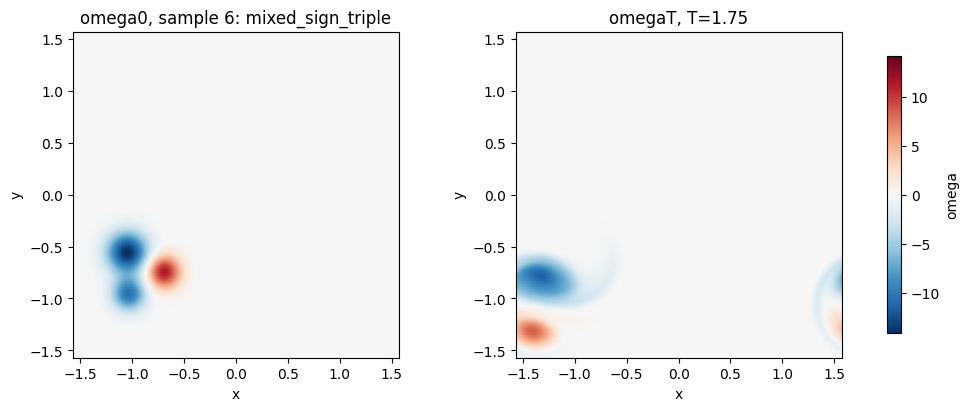

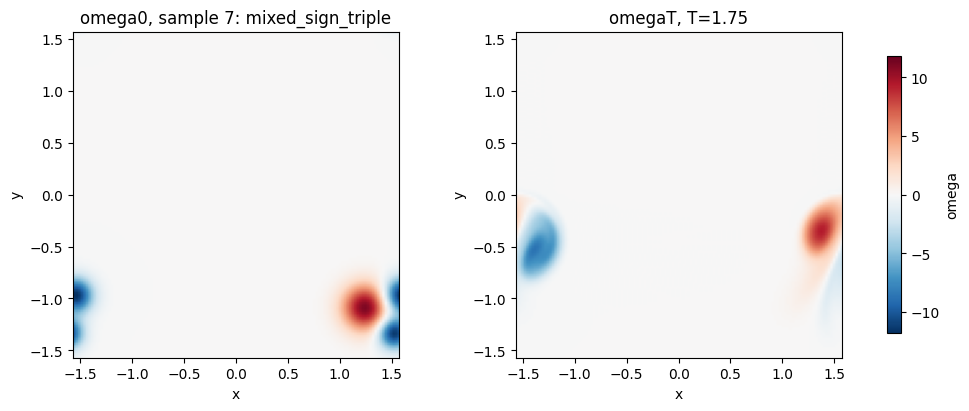

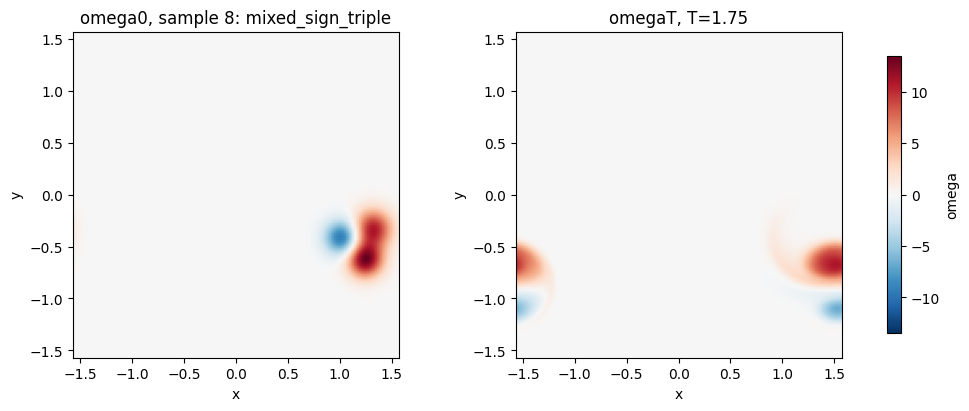

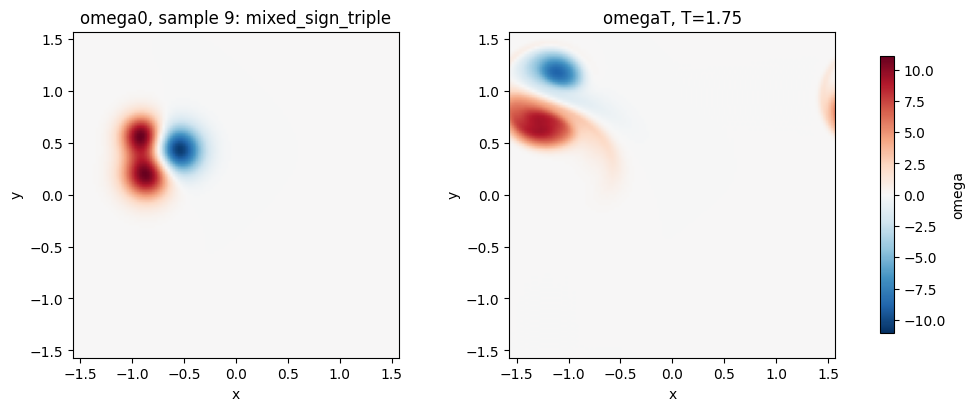

In [9]:
for idx in range(10):
    plot_sample(full_data, idx)

# Translation correction for edge-overlapping samples
Because the computational domain is periodic, a vortex can overlap with the boundary of the domain and appear split across opposite sides of the image. This representation is mathematically natural on the torus, but it makes the spatial structure less convenient for the convolutional inverse models to learn.

To avoid this issue, samples with vorticity values above a certain threshold at the image boundary (indicating they overlap and may be split across the image) are translated until both the initial and evolved fields lie away from the edges. The same discrete translation is applied to $\omega(0)$ and $\omega(T)$, so the translated pair still represents the same Navier-Stokes evolution, just in a shifted coordinate frame.

The corresponding vortex center coordinates are translated by the same amount. Samples that do not overlap the boundary are left unchanged.

In [10]:
def shift(field, n, m):
    return np.roll(field, shift=(n, m), axis=(0, 1))

def edge_size(field):
    return max(
        np.max(np.abs(field[0, :])),
        np.max(np.abs(field[-1, :])),
        np.max(np.abs(field[:, 0])),
        np.max(np.abs(field[:, -1]))
    )

def has_edge_overlap(omega1, omega2, threshold=1e-4):
    return (edge_size(omega1) > threshold) or (edge_size(omega2) > threshold)

def edge_correct(omega1, omega2, max_tries=1000, threshold=1e-4):
    # If already okay, keep it unchanged.
    if not has_edge_overlap(omega1, omega2, threshold):
        return omega1.copy(), omega2.copy(), 0, 0

    for _ in range(max_tries):
        n = int(rng.integers(N))
        m = int(rng.integers(N))

        omega1_shifted = shift(omega1, n, m)
        omega2_shifted = shift(omega2, n, m)

        if not has_edge_overlap(omega1_shifted, omega2_shifted, threshold):
            return omega1_shifted, omega2_shifted, n, m

    raise RuntimeError("Could not find a satisfactory shift.")

In [11]:
# Run this after running the data generator to shift clipped samples away from the edges
omega0 = full_data["omega0"]
parameters = full_data["parameters"]
active_vortex_mask = full_data["active_vortex_mask"]
vortex_count = full_data["vortex_count"]
pattern_name = full_data["pattern_name"]
omegaT = full_data["omegaT"]


omega0_augmented = np.zeros_like(omega0) 
omegaT_augmented = np.zeros_like(omegaT)
parameters_augmented = parameters.copy()

for i in range(len(omega0)):
    omega0_augmented[i], omegaT_augmented[i], n, m = edge_correct(omega0[i], omegaT[i])

    active = active_vortex_mask[i]

    parameters_augmented[i, active, 0] = wrap_to_domain(parameters[i, active, 0] + m * L / N)
    parameters_augmented[i, active, 1] = wrap_to_domain(parameters[i, active, 1] + n * L / N)


# "augmented" denotes the shifted version of data
full_data_augmented = {
        "omega0": omega0_augmented,
        "parameters": parameters_augmented,
        "active_vortex_mask": active_vortex_mask,
        "vortex_count": vortex_count,
        "pattern_name": pattern_name,
        "omegaT": omegaT_augmented
    }

# Inspect shifted examples

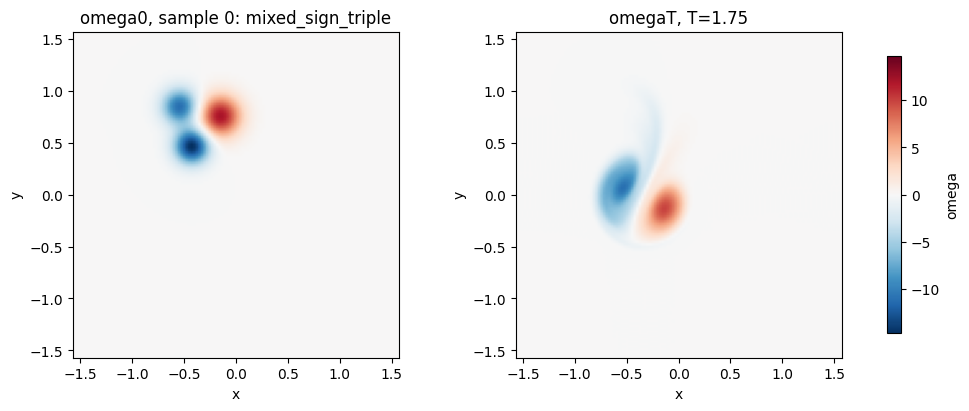

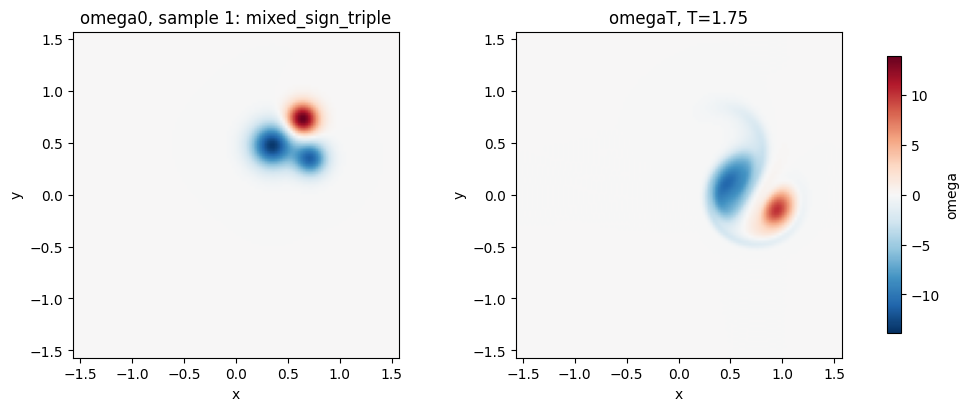

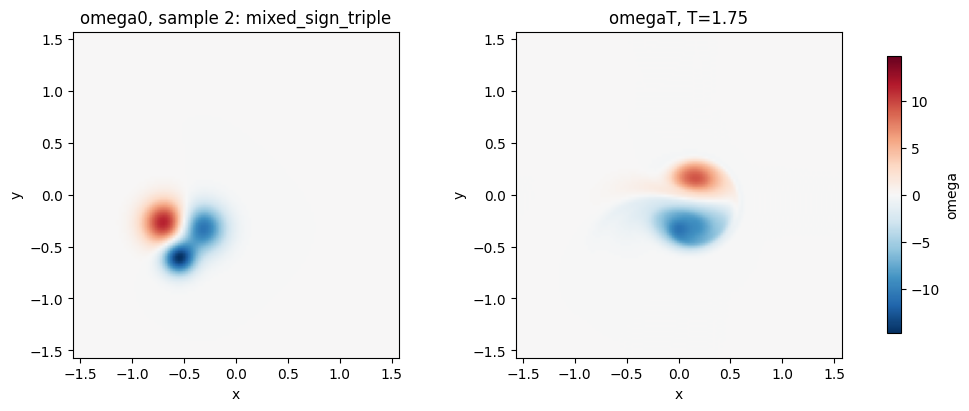

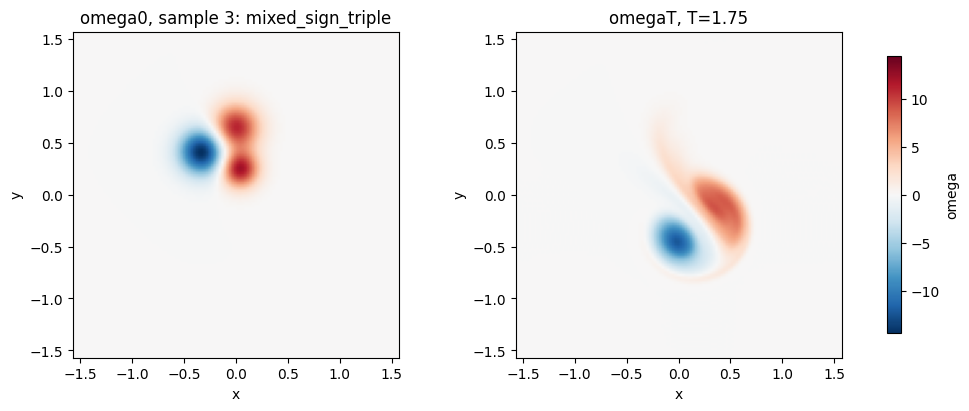

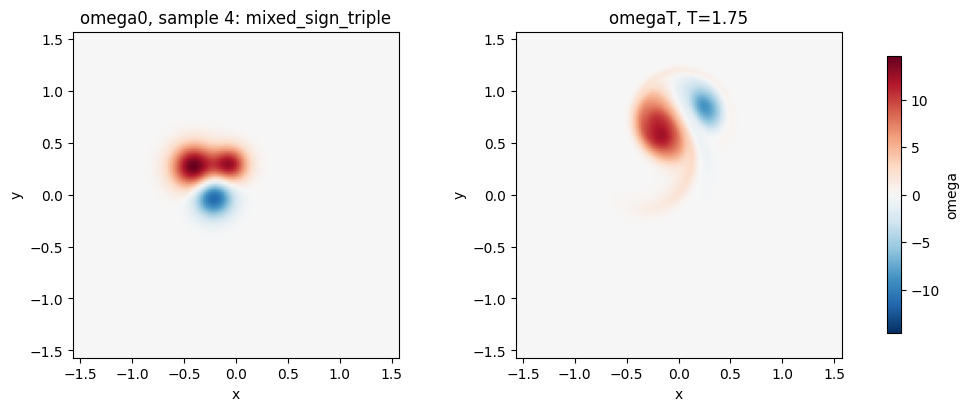

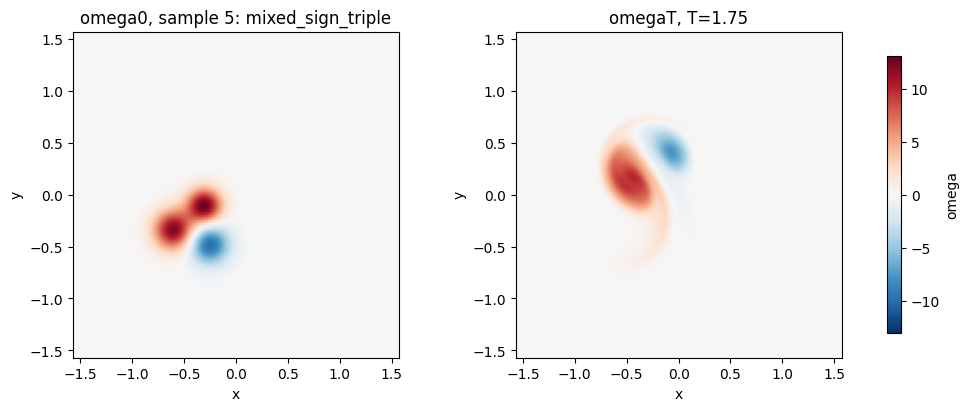

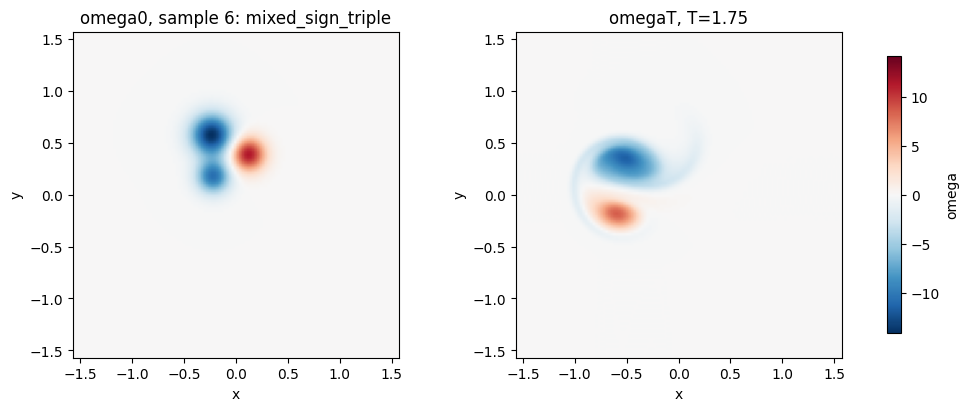

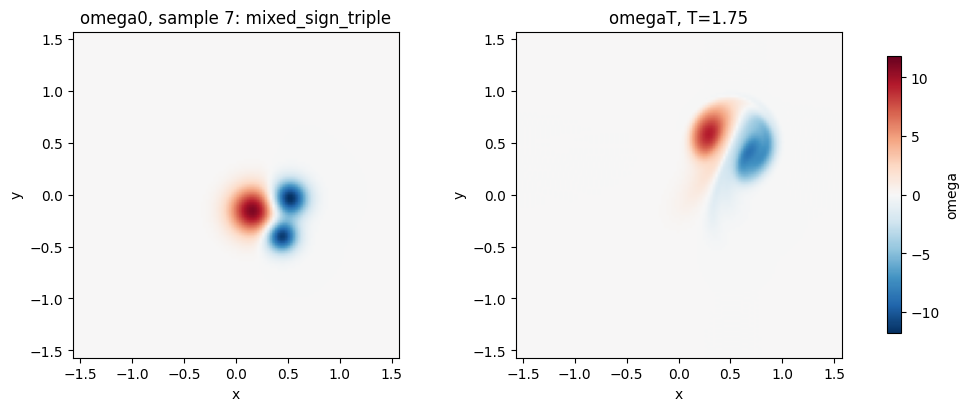

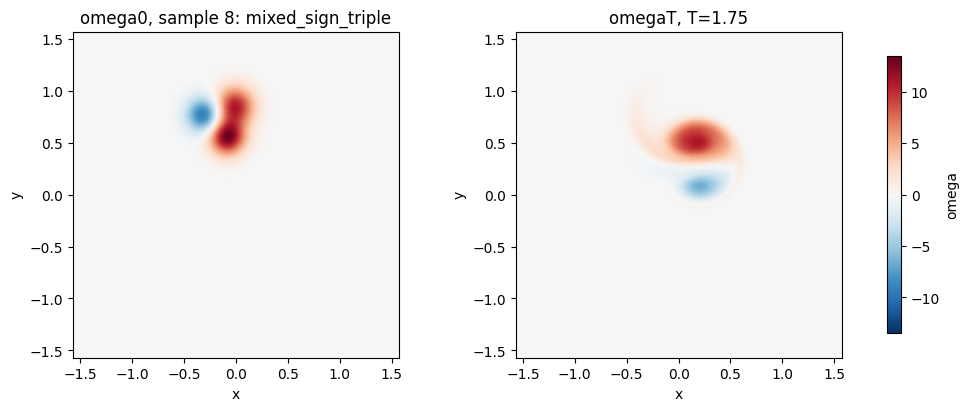

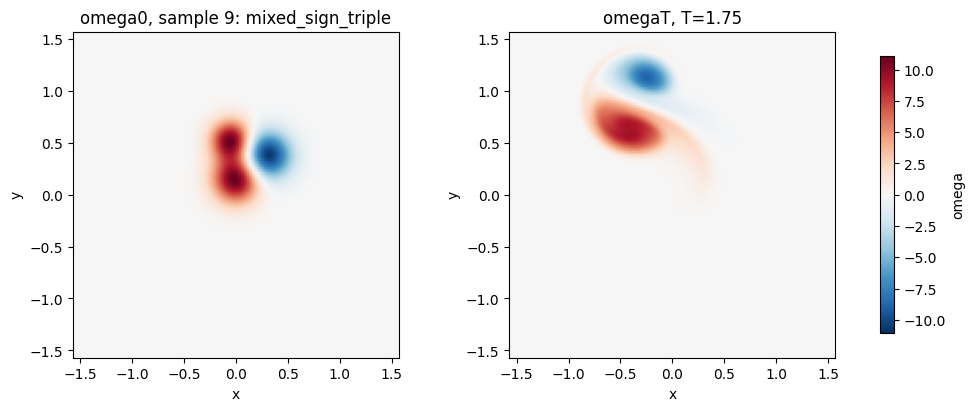

In [12]:
for idx in range(10):
    plot_sample(full_data_augmented, idx)

Notice that the examples in the earlier plot where the vortex structures came into contact with the boundary have been shifted, resulting in the plots above, in which none of the vortex structures do so.

# Save data
The completed dataset is saved as a compressed NumPy archive containing the initial and evolved vorticity fields, vortex parameters, active vortex masks, vortex counts, and the pattern label. The filename records the vortex family and number of generated samples.

In [13]:
SAVE_PATH = Path(f"vortex_{PATTERN}_{NUM_SAMPLES}_aug.npz")

np.savez_compressed(SAVE_PATH, **full_data_augmented)

print("saved to:", SAVE_PATH.resolve())

saved to: C:\Users\mbhnd\Documents\python notebooks\NS vortex cluster inverse solver\vortex_mixed_sign_triple_1000_aug.npz
